Time to take a look at the data. Let's check our input file. It should be an Excel file with multiple sheets.

In [1]:
import os

print(os.getcwd())

/Users/tanya/PyCharmProjects/dear-neighbour/python


In [3]:
input_file = "../data/dear_neighbour.xlsx"

In [3]:
import pathlib

file_path = pathlib.Path(input_file)
print(file_path.stat().st_size)

3856770


In [4]:
import openpyxl

wb = openpyxl.load_workbook(input_file)
print(wb.sheetnames)

['fact_sales', 'dim_products', 'dim_stores', 'dim_customers', 'dim_suppliers']


OK! Now we know that the file exists, is a valid Excel file, and has the expected sheet names.

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
sheets = pd.read_excel(input_file, sheet_name=None)

In [9]:
sheet_names = sheets.keys()
sheet_names

dict_keys(['fact_sales', 'dim_products', 'dim_stores', 'dim_customers', 'dim_suppliers'])

In [12]:
print(sheets['fact_sales'].info())

<class 'pandas.DataFrame'>
RangeIndex: 81238 entries, 0 to 81237
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   receipt_id        81238 non-null  int64         
 1   datetime          81238 non-null  datetime64[us]
 2   store_id          81238 non-null  int64         
 3   product_id        81238 non-null  int64         
 4   customer_id       44744 non-null  float64       
 5   quantity          81238 non-null  int64         
 6   unit_price        81238 non-null  float64       
 7   discount_percent  81238 non-null  int64         
 8   line_total        81238 non-null  float64       
 9   payment_method    81238 non-null  str           
dtypes: datetime64[us](1), float64(3), int64(5), str(1)
memory usage: 6.2 MB
None


In [ ]:
for sheet in sheets:
    print(f'Sheet name: {sheet}')
    for col in sheets[sheet].columns:
        print(f'\t{sheets[sheet][col].name}: {sheets[sheet][col].dtype}')


In [69]:
sales = sheets['fact_sales']
sales['date'] = sales['datetime'].dt.date

In [70]:
sales.sample()

,receipt_id,datetime,store_id,product_id,customer_id,quantity,unit_price,discount_percent,line_total,payment_method,date
23555,1006675,2024-08-10 14:38:00,8,92,1453.0,1,539.92,0,539.92,card,2024-08-10


<Axes: xlabel='datetime'>

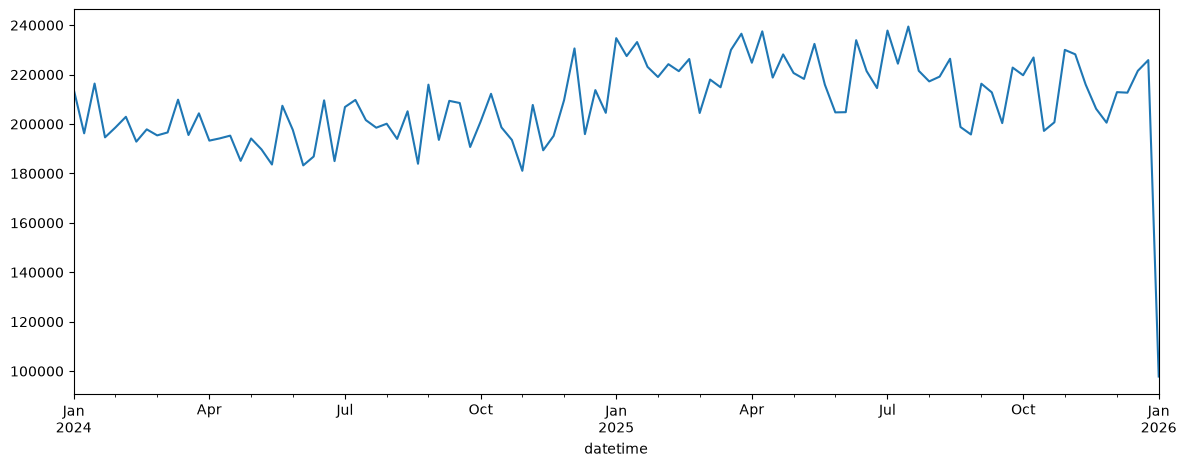

In [38]:
daily_sales = (
    sales
    .groupby(sales['datetime'].dt.to_period('W'))['line_total'].sum()  # try D, W, M, Q
)

daily_sales.plot(figsize=(14, 5))

In [92]:
store_sales = (
    sales
    .groupby('store_id')
    .agg(
        revenue=('line_total', 'sum'),
        receipts=('receipt_id', 'nunique'),
        lines=('receipt_id', 'count'),
    )
    .assign(
        revenue_K=lambda x: x['revenue'] / 1000,
        avg_receipt=lambda x: x['revenue'] / x['receipts'],
        avg_price=lambda x: x['revenue'] / x['lines'],
    )
    .sort_values('revenue', ascending=False)
)

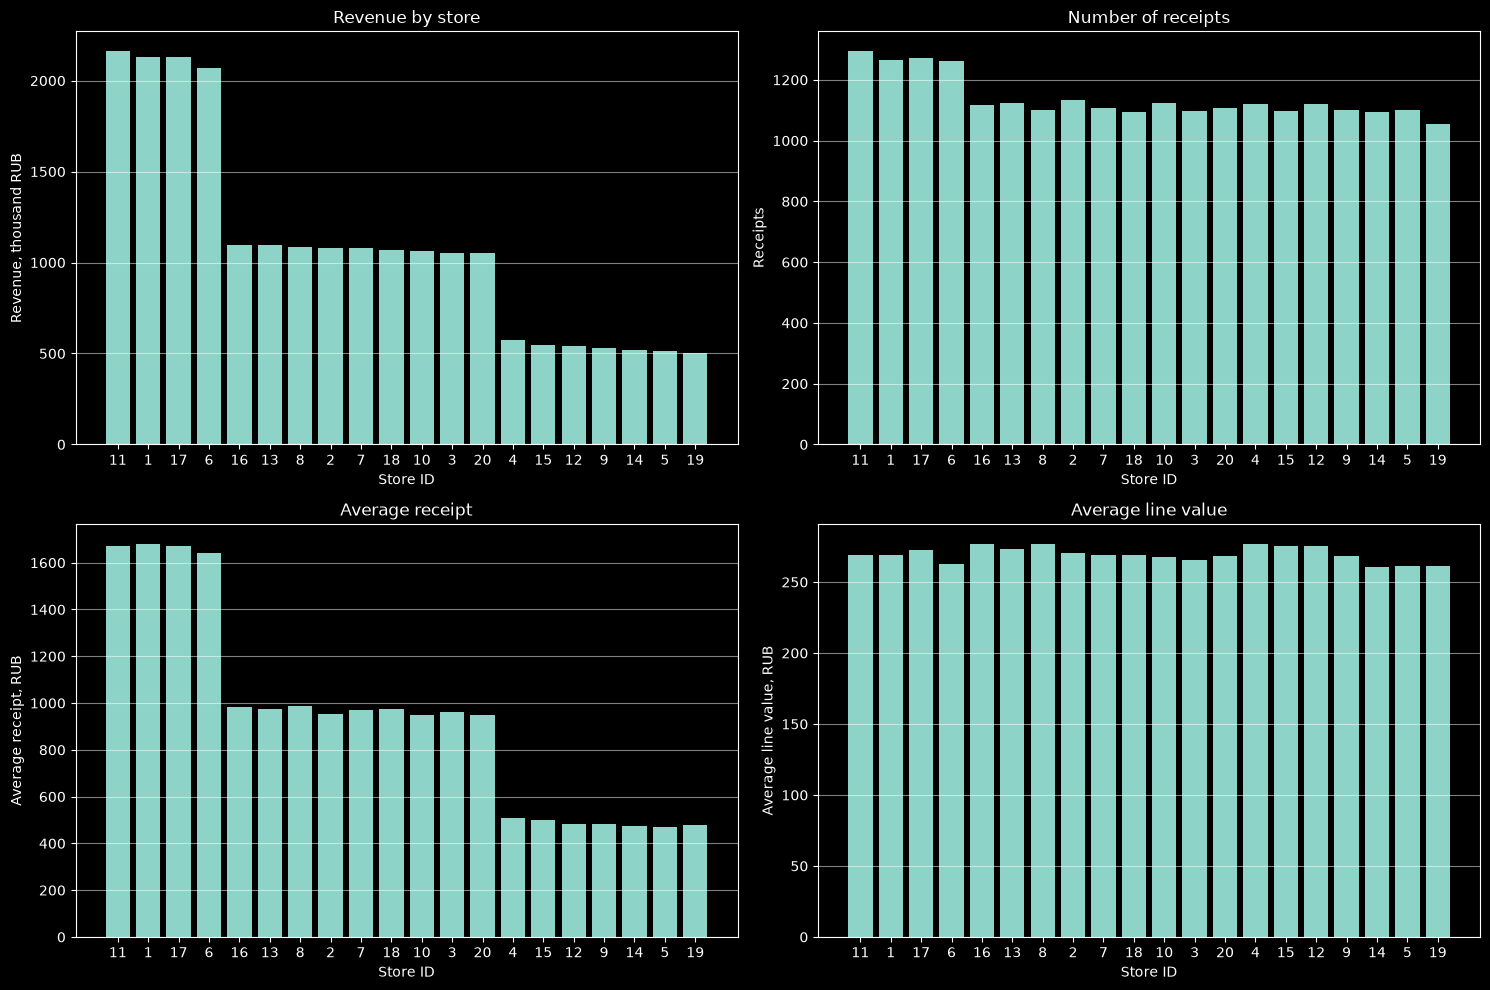

In [94]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

metrics = [
    ('revenue_K', 'Revenue by store', 'Revenue, thousand RUB'),
    ('receipts', 'Number of receipts', 'Receipts'),
    ('avg_receipt', 'Average receipt', 'Average receipt, RUB'),
    ('avg_price', 'Average line value', 'Average line value, RUB')
]

for ax, (column, title, ylabel) in zip(axes.flat, metrics):
    ax.bar(store_sales.index.astype(str), store_sales[column])

    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Store ID')
    ax.set_ylabel(ylabel)
    ax.grid(axis='y', alpha=0.5)

plt.tight_layout()
plt.show()

The number of receipts is roughly the same in large and small stores.

Also, at first glance, it seems that more expensive products are not in particularly high demand in larger stores.

Let's check the number of receipts per day.

In [134]:
random_date = sales['date'].sample(1).iloc[0]

random_date_footfall = (
    sales[sales['date'] == random_date]
    .groupby('store_id')
    .agg(receipts=('receipt_id', 'nunique'))
)

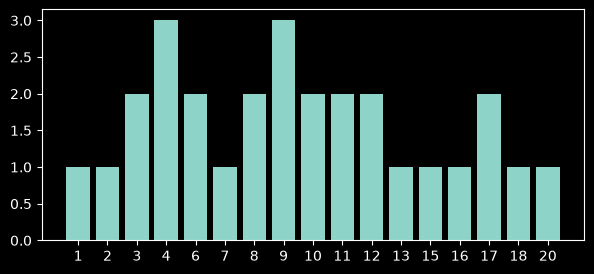

In [135]:
fig, ax = plt.subplots(1, 1, figsize=(7, 3))

ax.bar(random_date_footfall.index.astype(str), random_date_footfall['receipts'])
plt.show()

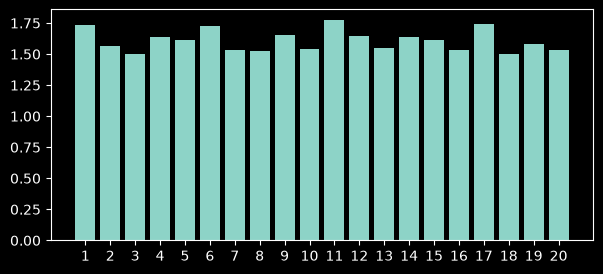

In [129]:
avg_daily_footfall = (
    sales.groupby(['store_id', sales['datetime'].dt.date])['receipt_id']
    .nunique()
    .groupby('store_id')
    .mean()
)

fig, ax = plt.subplots(1, 1, figsize=(7, 3))

ax.bar(avg_daily_footfall.index.astype(str), avg_daily_footfall)
plt.show()


It seems that these stores are not very popular among locals.